<a href="https://colab.research.google.com/github/rakesh-0918/Image_classification/blob/main/deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import cv2
import os
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

In [93]:
data_dir="/content/drive/MyDrive/image_classification/data/train"
happy="/content/drive/MyDrive/image_classification/data/train/happy"
sad="/content/drive/MyDrive/image_classification/data/train/sad"
image_exts=['jpeg','jpg','png','bmp']#thes extensions valid for images

In [94]:
os.listdir(data_dir)# it list all directiories which are present in the data folder

['happy', 'sad']

In [95]:
os.listdir(os.path.join(data_dir,'happy'))# it list all images in happy folder

['Training_62881265.jpg',
 'Training_70706185.jpg',
 'Training_65147985.jpg',
 'Training_3469671.jpg',
 'Training_48707061.jpg',
 'Training_84197631.jpg',
 'Training_68142837.jpg',
 'Training_3815265.jpg',
 'Training_52423657.jpg',
 'Training_82699722.jpg',
 'Training_43962024.jpg',
 'Training_5478628.jpg',
 'Training_40630936.jpg',
 'Training_74886043.jpg',
 'Training_94517827.jpg',
 'Training_50207076.jpg',
 'Training_4291394.jpg',
 'Training_69151239.jpg',
 'Training_67491344.jpg',
 'Training_88388137.jpg',
 'Training_74576949.jpg',
 'Training_78839531.jpg',
 'Training_42063182.jpg',
 'Training_68738260.jpg',
 'Training_65138035.jpg',
 'Training_6251569.jpg',
 'Training_72527998.jpg',
 'Training_74654028.jpg',
 'Training_98288638.jpg',
 'Training_71678330.jpg',
 'Training_77222637.jpg',
 'Training_99371172.jpg',
 'Training_37503027.jpg',
 'Training_87976258.jpg',
 'Training_65887296.jpg',
 'Training_39160872.jpg',
 'Training_61541968.jpg',
 'Training_95890455.jpg',
 'Training_840974



## **---Remove the otherthan image extension**



In [96]:
for imageclass in os.listdir(data_dir):# it gives all list of directories in data
  if imageclass.startswith('.'):
    continue
  else:
    print(imageclass)

happy
sad


In [97]:
for imageclass in os.listdir(data_dir):
    if imageclass.startswith('.'):
        continue
    else:
        for image in os.listdir(os.path.join(data_dir, imageclass)):
            image_path = os.path.join(data_dir, imageclass, image)
            try:
                img = cv2.imread(image_path)
                tip = Image.open(image_path).format
                tip = tip.lower() if tip else None

                if img is None or tip not in image_exts:
                    print('Image not in ext list {}'.format(image_path))
                    os.remove(image_path)
            except Exception as e:
                print('Issue with image {}'.format(image_path))
                os.remove(image_path)

array([[[163, 163, 163],
        [153, 153, 153],
        [147, 147, 147],
        ...,
        [179, 179, 179],
        [ 81,  81,  81],
        [ 31,  31,  31]],

       [[155, 155, 155],
        [153, 153, 153],
        [154, 154, 154],
        ...,
        [176, 176, 176],
        [147, 147, 147],
        [ 40,  40,  40]],

       [[156, 156, 156],
        [158, 158, 158],
        [148, 148, 148],
        ...,
        [139, 139, 139],
        [163, 163, 163],
        [ 83,  83,  83]],

       ...,

       [[166, 166, 166],
        [165, 165, 165],
        [162, 162, 162],
        ...,
        [  0,   0,   0],
        [  8,   8,   8],
        [ 55,  55,  55]],

       [[168, 168, 168],
        [166, 166, 166],
        [163, 163, 163],
        ...,
        [  5,   5,   5],
        [  6,   6,   6],
        [ 42,  42,  42]],

       [[167, 167, 167],
        [163, 163, 163],
        [161, 161, 161],
        ...,
        [  1,   1,   1],
        [  8,   8,   8],
        [ 45,  45,  45]]], dtype=uint8)
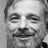

In [98]:
img=cv2.imread(os.path.join(data_dir,happy,"Training_84163741.jpg"))# image is colored but not in rgb
img

In [99]:
import cv2, os

small_count = 0
total = 0
for cls in ['happy', 'sad']:
    folder = os.path.join(data_dir, cls)
    for f in os.listdir(folder):
        total += 1
        img = cv2.imread(os.path.join(folder, f))
        if img is not None and (img.shape[0] < 100 or img.shape[1] < 100):
            small_count += 1

print(f"{small_count}/{total} images are smaller than 100x100")

8977/8977 images are smaller than 100x100


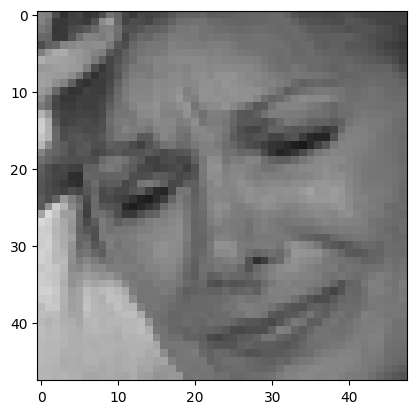

In [100]:
plt.imshow(img)

# **Load Data**

In [101]:
tf.data.Dataset

tensorflow.python.data.ops.dataset_ops.DatasetV2

In [125]:
data=tf.keras.utils.image_dataset_from_directory(data_dir, image_size=(48, 48),color_mode='grayscale')# it loads image from folder and turn them into a data set for training
type(data)
print(data.class_names)

Found 8977 files belonging to 2 classes.
['happy', 'sad']


In [127]:
#iteration the contents
data_iterator=data.as_numpy_iterator()
data_iterator

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x7ed968605950>)

In [128]:
#Labeling
batch=data_iterator.next()
print(batch[1])# 0 means happy 1 means sad

[0 1 1 1 1 0 1 0 1 1 1 1 0 1 0 0 0 0 1 1 0 0 1 1 1 0 0 1 1 0 1 1]


In [129]:
#Images shown as numpy arrays
print(batch[0])

[[[[165.]
   [165.]
   [166.]
   ...
   [198.]
   [198.]
   [149.]]

  [[166.]
   [166.]
   [166.]
   ...
   [182.]
   [193.]
   [194.]]

  [[167.]
   [166.]
   [166.]
   ...
   [188.]
   [183.]
   [184.]]

  ...

  [[ 87.]
   [ 99.]
   [107.]
   ...
   [  0.]
   [  2.]
   [  9.]]

  [[ 84.]
   [100.]
   [ 91.]
   ...
   [ 38.]
   [ 24.]
   [ 15.]]

  [[ 93.]
   [ 92.]
   [ 90.]
   ...
   [ 87.]
   [ 85.]
   [ 87.]]]


 [[[ 51.]
   [ 63.]
   [ 72.]
   ...
   [104.]
   [111.]
   [ 98.]]

  [[ 40.]
   [ 59.]
   [ 78.]
   ...
   [ 93.]
   [101.]
   [ 97.]]

  [[ 43.]
   [ 57.]
   [ 84.]
   ...
   [ 75.]
   [ 99.]
   [ 89.]]

  ...

  [[119.]
   [115.]
   [114.]
   ...
   [120.]
   [107.]
   [ 81.]]

  [[106.]
   [120.]
   [119.]
   ...
   [115.]
   [ 98.]
   [ 63.]]

  [[ 83.]
   [117.]
   [121.]
   ...
   [109.]
   [ 88.]
   [ 47.]]]


 [[[ 90.]
   [ 90.]
   [ 92.]
   ...
   [201.]
   [195.]
   [192.]]

  [[ 89.]
   [ 90.]
   [ 93.]
   ...
   [201.]
   [197.]
   [198.]]

  [[ 90.]
   [ 9

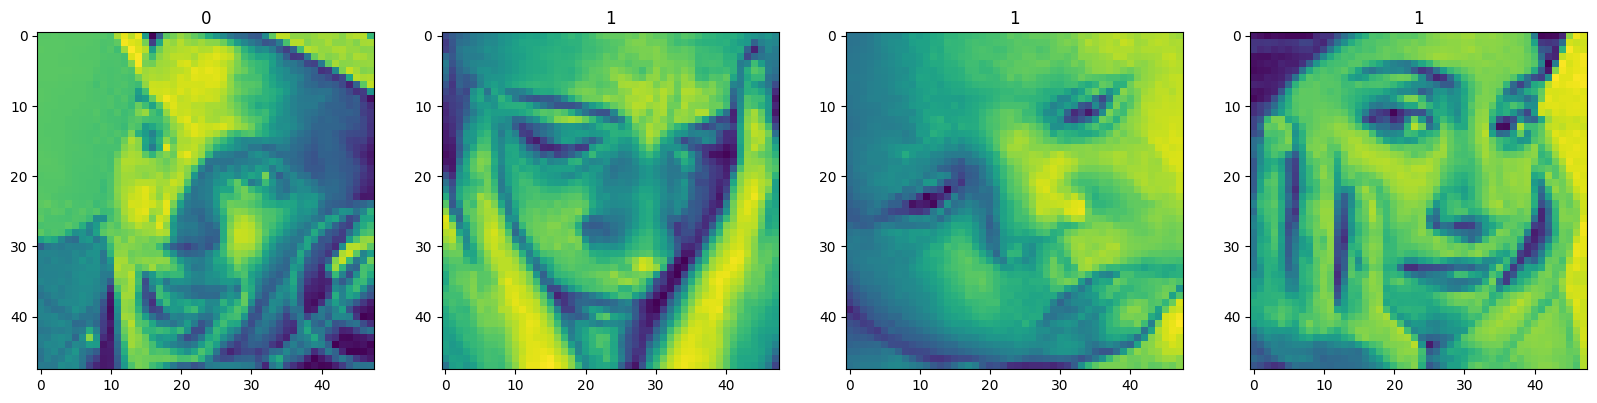

In [130]:
fig,ax=plt.subplots(ncols=4,figsize=(20,20))
for idx,img in enumerate(batch[0][:4]):
  ax[idx].imshow(img.astype(int))
  ax[idx].title.set_text(batch[1][idx])

# **Preprocessing Data**

In [131]:
#Scaling/Normalisation data in between 0 to 1
data=data.map(lambda x,y:(x/255,y))# x is image y is label
scaled_iterator=data.as_numpy_iterator()
batch=scaled_iterator.next()
batch[0]

array([[[[0.6       ],
         [0.58431375],
         [0.5647059 ],
         ...,
         [0.23921569],
         [0.32941177],
         [0.30588236]],

        [[0.58431375],
         [0.58431375],
         [0.5764706 ],
         ...,
         [0.21176471],
         [0.3019608 ],
         [0.30980393]],

        [[0.5882353 ],
         [0.58431375],
         [0.5764706 ],
         ...,
         [0.19215687],
         [0.27450982],
         [0.3254902 ]],

        ...,

        [[0.14509805],
         [0.14901961],
         [0.12156863],
         ...,
         [0.10196079],
         [0.13333334],
         [0.13725491]],

        [[0.14117648],
         [0.14117648],
         [0.12941177],
         ...,
         [0.14509805],
         [0.15686275],
         [0.16078432]],

        [[0.14117648],
         [0.14117648],
         [0.12941177],
         ...,
         [0.16078432],
         [0.17254902],
         [0.16078432]]],


       [[[0.9529412 ],
         [0.9254902 ],
         [0.90

In [132]:
print(batch[0].min())
print(batch[1].max())

0.0
1


# Spilting **Data**

In [133]:
len(data)# how many batches in data set

281

In [134]:
# split the data into 80 % for training 20% for validation
train_size=int(len(data) * .8)
val_size=int(len(data)*.2)+1

print(train_size)
print(val_size)

224
57


In [135]:
train=data.take(train_size)
val=data.skip(train_size).take(val_size)

# **Deep learning**

In [114]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import Sequential, layers

In [137]:
model = Sequential([
    layers.Input(shape=(48,48,1)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.Conv2D(16,(3,3),activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32,(3,3),activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(64,activation="relu"),
    layers.Dense(1,activation="sigmoid")
])



In [138]:
model.compile("adam",loss=tf.losses.BinaryCrossentropy(),metrics=["accuracy"])

In [139]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_6 (RandomFlip)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_6               │ (None, 48, 48, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 46, 46, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 23, 23, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 21, 21, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 10, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,521 (107.50 KB)

 Trainable params: 27,521 (107.50 KB)

 Non-trainable params: 0 (0.00 B)

# **Training**

In [141]:
logs="/content/drive/MyDrive/image_classification/logs"
logdir="logs"

In [143]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)#a tool that records how your model is learning so you can see it as graphs.

In [145]:
es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True)

hist = model.fit(train, epochs=50, validation_data=val,
                 callbacks=[tensorboard_callback, es])

Epoch 1/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 18s 82ms/step - accuracy: 0.7040 - loss: 0.5721 - val_accuracy: 0.7297 - val_loss: 0.5493
Epoch 2/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.7118 - loss: 0.5638 - val_accuracy: 0.7214 - val_loss: 0.5554
Epoch 3/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - accuracy: 0.7174 - loss: 0.5589 - val_accuracy: 0.7358 - val_loss: 0.5391
Epoch 4/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 20s 87ms/step - accuracy: 0.7218 - loss: 0.5519 - val_accuracy: 0.7441 - val_loss: 0.5255
Epoch 5/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 18s 82ms/step - accuracy: 0.7267 - loss: 0.5441 - val_accuracy: 0.7496 - val_loss: 0.5338
Epoch 6/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - accuracy: 0.7341 - loss: 0.5357 - val_accuracy: 0.7435 - val_loss: 0.5246
Epoch 7/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 18s 80ms/step - accuracy: 0.7394 - loss: 0.5296 - val_accuracy: 0.7396 - val_loss: 0.5417
Epoch 8/50
224/224 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - accuracy: 0.7405 - loss: 0.5245 - 

In [147]:
print(len(hist.history['loss']))   # confirms how many epochs actually ran before stopping

25


In [148]:
model.evaluate(val)

57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.8192 - loss: 0.4055


[0.40548089146614075, 0.8192371726036072]

In [149]:
hist

In [150]:
hist.history

{'accuracy': [0.7039620280265808,
  0.7117745280265808,
  0.7173548936843872,
  0.7218192219734192,
  0.7267020344734192,
  0.7340959906578064,
  0.7393973469734192,
  0.7405133843421936,
  0.7523716688156128,
  0.7488839030265808,
  0.7578125,
  0.7638114094734192,
  0.7681361436843872,
  0.7741350531578064,
  0.7696707844734192,
  0.7777622938156128,
  0.783203125,
  0.7859932780265808,
  0.7915736436843872,
  0.7942243218421936,
  0.8048270344734192,
  0.7873883843421936,
  0.7999442219734192,
  0.8048270344734192,
  0.8046875],
 'loss': [0.5721288919448853,
  0.5638412237167358,
  0.5588868856430054,
  0.551941454410553,
  0.5440847277641296,
  0.5356720685958862,
  0.5296360850334167,
  0.5244700312614441,
  0.5117505788803101,
  0.508080244064331,
  0.5043969750404358,
  0.4905044436454773,
  0.48721548914909363,
  0.47487449645996094,
  0.46950381994247437,
  0.46776434779167175,
  0.46546849608421326,
  0.45333147048950195,
  0.45448875427246094,
  0.44335633516311646,
  0.4342

# **Plot performance**

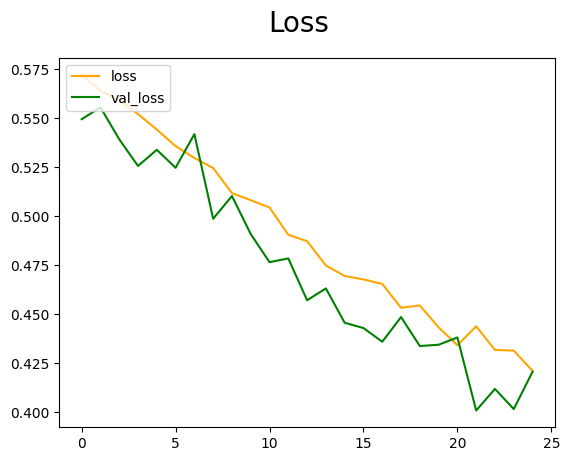

In [151]:
#visualizing loss and validation loss
fig=plt.figure()
plt.plot(hist.history['loss'],color='orange',label='loss')
plt.plot(hist.history['val_loss'],color='green',label='val_loss')
fig.suptitle('Loss',fontsize=20)
plt.legend(loc="upper left")
plt.show()

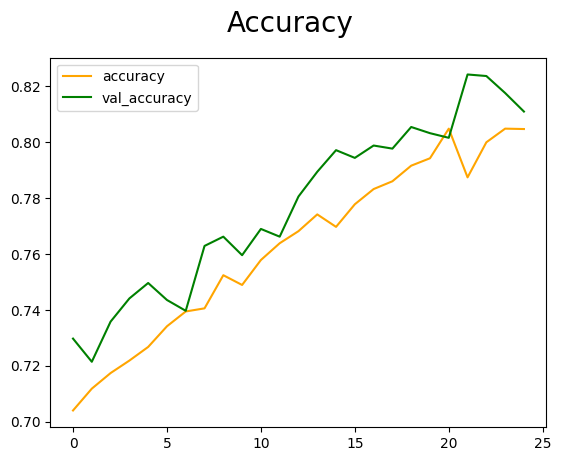

In [152]:
# visualize on accuracy
fig=plt.figure()
plt.plot(hist.history['accuracy'],color='orange',label='accuracy')
plt.plot(hist.history['val_accuracy'],color='green',label='val_accuracy')
fig.suptitle('Accuracy',fontsize=20)
plt.legend(loc="upper left")
plt.show()

# **Evaluate Performance**

In [153]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [154]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [156]:
test = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/image_classification/data/test',   # adjust if path differs
    image_size=(48,48),
    color_mode='grayscale',
    shuffle=False
)
test = test.map(lambda x, y: (x/255.0, y))

Found 12045 files belonging to 2 classes.


In [157]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

print(f'Precision:{pre.result().numpy()} , Recall:{re.result().numpy()},Accuracy:{ acc.result().numpy()}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━


# **Testing**



In [164]:
def predict_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resize = tf.image.resize(img[..., np.newaxis], (48,48))
    img_normalized = resize.numpy() / 255.0
    img_input = np.expand_dims(img_normalized, 0)

    prediction = model.predict(img_input, verbose=0)
    label = "sad" if prediction[0][0] > 0.5 else "happy"
    print(f"Predicted: {label} (raw: {prediction[0][0]:.4f})")

    plt.imshow(img_normalized.squeeze(), cmap='gray')
    plt.title(label)
    plt.show()



Predicted: happy (raw: 0.2974)


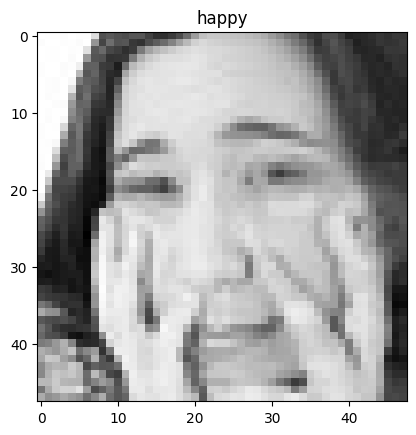

In [172]:
predict_image('/content/drive/MyDrive/image_classification/data/test/sad/Training_10642717.jpg')

# **Save the Model**

In [178]:
from tensorflow.keras.models import load_model

In [181]:
model.save(os.path.join('/content/drive/MyDrive/image_classification/model','happysadmodel.keras'))

In [182]:
model = load_model('/content/drive/MyDrive/image_classification/model/happysadmodel.keras')

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [183]:
model.evaluate(val)

57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.8214 - loss: 0.4040


[0.4040256440639496, 0.8214483261108398]